<a href="https://colab.research.google.com/github/KINGDAUDA/Data-Centers-USA/blob/main/Data_Centers_USA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%pip install iso3166

In [ ]:
%pip install openpyxl

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from iso3166 import countries
from datetime import timedelta
import re
import plotly.graph_objects as go

In [ ]:
pd.options.display.float_format = '{:,.2f}'.format

# Columns and Shape of Dataset

In [ ]:
df_raw = pd.read_excel("data_centers.xlsx")

In [ ]:
print(df_raw.shape)
print(df_raw.columns)

(1621, 44)
Index(['facility_name', 'address', 'city', 'state', 'zip', 'county', 'lat',
       'long', 'status', 'location_confidence', 'purpose', 'operator_name',
       'tenant', 'mw', 'sizerank', 'power_source', 'dedicated_power_plant',
       'number_of_generators', 'number_of_buildings', 'cooling_source',
       'cooling_type', 'facility_size_sqft', 'property_size_acres',
       'project_cost', 'expected_date_online', 'community_pushback',
       'advocacy_information', 'resistance_status', 'nda',
       'community_group_website_1', 'community_group_website_2',
       'petition_url', 'other_info', 'information_source', 'info_source_1',
       'info_source_2', 'info_source_3', 'info_source_4', 'info_source_5',
       'info_source_6', 'info_source_7', 'info_source_8', 'date_created',
       'date_updated'],
      dtype='object')


## Are there any NaN or Duplicate Values?

In [ ]:
df_raw.duplicated().sum()

np.int64(0)

In [ ]:
df_raw.isna().sum()

,0
facility_name,2
address,60
city,5
state,1
zip,51
county,3
lat,0
long,0
status,0
location_confidence,7


## Cleaning and Sanitizing the dataset for Analysis

In [ ]:
# Reload dataset
df = pd.read_excel("data_centers.xlsx", sheet_name="FracTracker Data Centers")

# 1. Strip whitespace from all string columns
str_cols = df.select_dtypes(include="object").columns
df[str_cols] = df[str_cols].apply(lambda x: x.str.strip())

# 2. Impute known missing geographic details
# Row 0: Calistoga, Napa County, CA
df.loc[df["facility_name"] == "Global Stack Data Center", ["city", "state"]] = [
    "Calistoga",
    "CA",
]

# Impute missing counties based on city & coordinates
df.loc[
    (df["city"] == "Epping") & (df["state"] == "ND"), "county"
] = "Williams"
df.loc[
    (df["city"] == "Mount Royal") & (df["state"] == "NJ"), "county"
] = "Gloucester"
df.loc[
    (df["city"] == "Lancaster") & (df["state"] == "TX"), "county"
] = "Dallas"

# Fill remaining null cities and counties for hierarchical charting
df["city"] = df["city"].fillna("Unincorporated / Undisclosed")
df["county"] = df["county"].fillna("Unknown County")

# 3. Clean categorical inconsistencies
df["sizerank"] = df["sizerank"].replace(
    "Hyperscale (101-999 MW)", "Hyperscale (100-999 MW)"
)
df["community_pushback"] = df["community_pushback"].fillna("Unknown")

# 4. Standardize Status into broad stages
status_map = {
    "Operating": "Operating",
    "Expanding": "Operating",
    "Proposed": "Proposed",
    "Pre-proposal": "Proposed",
    "Approved/Permitted/Under construction": "Under Construction / Permitted",
    "Suspended": "Suspended / Cancelled",
    "Cancelled": "Suspended / Cancelled",
}
df["status_group"] = df["status"].map(status_map)


# 5. Parse 'mw' column into numeric (handling ranges like '100-200', '1,000+', etc.)
def parse_mw(val):
    if pd.isna(val):
        return np.nan
    val = str(val).replace(",", "").replace("+", "").replace("?", "").strip()
    # Check for range: '100-200' or '12–20'
    m = re.match(r"^(\d+(?:\.\d+)?)\s*[-–]\s*(\d+(?:\.\d+)?)$", val)
    if m:
        return (float(m.group(1)) + float(m.group(2))) / 2.0
    try:
        return float(val)
    except ValueError:
        return np.nan


df["mw_clean"] = df["mw"].apply(parse_mw)

print("Sanitization complete. Clean shape:", df.shape)

Sanitization complete. Clean shape: (1621, 46)


In [ ]:
# Convert valid floats to integers, then string, and restore leading zeros
df['zip'] = (
    df['zip']
    .dropna()
    .astype(int)
    .astype(str)
    .str.zfill(5)
)

# Verify results
print(df[['facility_name', 'state', 'zip']].dropna().head(10))

                               facility_name state    zip
2                    Prudhoe Bay Data Center    AK  99734
3                   Grant County Data Center    AK  72150
4                             Project Marvel    AL  35022
5                   BHM01 Nebius Data Center    AL  35221
6                                    DC Blox    AL  35233
7                         Google Data Center    AL  35740
8   Western Hospitality Partners Data Center    AL  35044
9                                    DC Blox    AL  35806
10                          Meta Data Center    AL  35810
11                          Meta Data Center    AL  36105


## Module 1: Geographic Distribution & Hierarchy
1. How is data center capacity
concentrated geographically across the US?

- What are the top 5 states by
facility count?

- Within leading states (e.g., Virginia, Texas, California), which specific counties account for the clustering?

2. What does the administrative hierarchy look like?

- Build the Sunburst Chart (State -> County -> City) to visualize regional dominance (e.g., Northern Virginia / Loudoun County dominance).

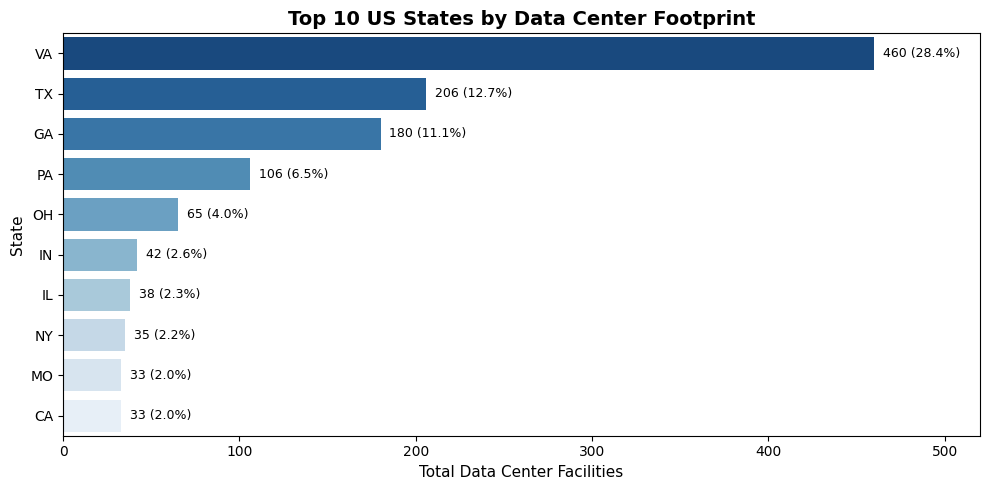

In [ ]:
# Calculate state shares
state_data = (
    df["state"]
    .value_counts()
    .head(10)
    .reset_index(name="count")
    .rename(columns={"index": "state"})
)

plt.figure(figsize=(10, 5))
palette = sns.color_palette("Blues_r", n_colors=10)

barplot = sns.barplot(
    data=state_data,
    x="count",
    y="state",
    hue="state",
    palette=palette,
    legend=False,
)

plt.title("Top 10 US States by Data Center Footprint", fontsize=14, weight="bold")
plt.xlabel("Total Data Center Facilities", fontsize=11)
plt.ylabel("State", fontsize=11)

# Annotate bars with counts and percentages
total_dcs = len(df)
for p in barplot.patches:
    val = int(p.get_width())
    pct = (val / total_dcs) * 100
    barplot.annotate(
        f"{val:,} ({pct:.1f}%)",
        (val + 5, p.get_y() + p.get_height() / 2),
        va="center",
        fontsize=9,
    )

plt.xlim(0, 520)
plt.tight_layout()
plt.show()

In [ ]:
# Prepare count aggregations
hierarchy_df = (
    df.groupby(["state", "county", "city"]).size().reset_index(name="count")
)

# Plotly Sunburst
fig = px.sunburst(
    hierarchy_df,
    path=["state", "county", "city"],
    values="count",
    title="US Data Center Footprint: State -> County -> City Hierarchy",
    # color="count",
    # color_continuous_scale="matter",
    width=1200,
    height=800,
)

fig.update_layout(margin=dict(t=50, l=10, r=10, b=10))
fig.show()

## Module 2: Development Pipeline & Lifecycle
1. What share of the national footprint is active vs. speculative?

- What is the breakdown of status (Operating vs. Proposed vs. Under Construction vs. Cancelled/Suspended)?

2. Where is future capacity heading?

- Which states/counties have the highest concentration of Proposed sites versus already Operating facilities?

In [ ]:
# 1. Filter top 10 states
top10_states = df["state"].value_counts().head(10).index
pipe_df = df[df["state"].isin(top10_states)]

# 2. Build cross-tabulation: counts and normalized percentages
stage_order = [
    "Operating",
    "Under Construction / Permitted",
    "Proposed",
    "Suspended / Cancelled",
]

# Raw facility counts
ct_counts = pd.crosstab(pipe_df["state"], pipe_df["status_group"]).loc[
    top10_states, stage_order
]

# Normalized percentage shares (0-100%)
state_totals = ct_counts.sum(axis=1)
ct_pcts = (
    ct_counts.div(state_totals, axis=0) * 100
).round(1)

# Palette mapping
colors = {
    "Operating": "#1e3a8a",
    "Under Construction / Permitted": "#2563eb",
    "Proposed": "#60a5fa",
    "Suspended / Cancelled": "#9ca3af",
}

# 3. Construct Figure explicitly with graph_objects
fig2 = go.Figure()

for stage in stage_order:
    fig2.add_trace(
        go.Bar(
            name=stage,
            y=ct_counts.index,
            x=ct_pcts[stage],
            orientation="h",
            marker_color=colors[stage],
            customdata=list(
                zip(ct_counts[stage], state_totals)
            ),  # Direct tuple binding per stage
            hovertemplate=(
                "<b>State: %{y}</b><br>"
                + f"Stage: {stage}<br>"
                + "Facilities: %{customdata[0]:,} of %{customdata[1]:,}<br>"
                + "Share of State: %{x:.1f}%<extra></extra>"
            ),
        )
    )

fig2.update_layout(
    title="Data Center Lifecycle Breakdown Across Top 10 States (% Share)",
    barmode="stack",
    height=800,
    width=1300,
    xaxis=dict(ticksuffix="%", range=[0, 100], title="Share of State Fleet"),
    yaxis=dict(autorange="reversed", title="State"),
    legend=dict(
        orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1
    ),
    hovermode="closest",
)

fig2.show()

## Module 3: Sizing & Megawatt (MW) Capacity
1. What is the distribution of facility sizes across the nation?

- What proportion of facilities fall into Hyperscale, Large, Medium, Small, or Mega campus categories via sizerank?

2. For facilities with disclosed power (mw), what is the scale?

- After parsing mw to numeric, what are the median and interquartile ranges (IQR) of power demand across facility tiers? (Avoid raw means due to extreme skewness).

In [ ]:
# Prepare cross-tabulation without 'Unknown' to highlight disclosed capacity
tier_pipeline = (
    df[df["sizerank"] != "Unknown"]
    .groupby(["sizerank", "status_group"])
    .size()
    .reset_index(name="count")
)

tier_order = [
    "Small (0-10 MW)",
    "Medium (11-50 MW)",
    "Large (51-99 MW)",
    "Hyperscale (100-999 MW)",
    "Mega campus (>1,000 MW)",
]

fig3_bar = px.bar(
    tier_pipeline,
    x="sizerank",
    y="count",
    color="status_group",
    category_orders={"sizerank": tier_order},
    barmode="group",
    title="Data Center Facility Count by Size Tier and Lifecycle Stage",
    labels={
        "sizerank": "Facility Capacity Tier",
        "count": "Number of Facilities",
        "status_group": "Status",
    },
    color_discrete_map={
        "Operating": "#1e3a8a",
        "Under Construction / Permitted": "#2563eb",
        "Proposed": "#60a5fa",
        "Suspended / Cancelled": "#9ca3af",
    },
)

fig3_bar.update_layout(
    height=800,
    width=1300,
    legend=dict(
        orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1
    ),
)
fig3_bar.show()

In [ ]:
# Filter rows that have clean parsed MW values
mw_plot_df = df[df["mw_clean"].notna() & (df["sizerank"] != "Unknown")].copy()

fig3_box = px.box(
    mw_plot_df,
    x="sizerank",
    y="mw_clean",
    color="sizerank",
    category_orders={"sizerank": tier_order},
    points="all",  # Overlays individual data points with jitter
    log_y=True,  # Crucial: Log scale accounts for 1 MW to 10,000 MW spread
    title="Disclosed Power Demand (MW) Distribution Across Tiers (Log Scale)",
    labels={"sizerank": "Size Tier", "mw_clean": "Disclosed Capacity (MW)"},
    hover_data=["facility_name", "state", "operator_name", "status"],
)

fig3_box.update_layout(
    height=800,
    width=1350,
    showlegend=False,
    yaxis=dict(title="Disclosed Megawatts (MW) - Log10 Scale"),
)

fig3_box.show()

## Module 4: Operator Landscape & Market Share
1. Who controls the infrastructure: Big Tech vs. Infrastructure Developers?

- Who are the top 10 operators by facility count?

- How do Big Tech hyperscalers (Amazon/AWS, Microsoft, Google, Meta) compare to colocation and wholesale REITs (Digital Realty, Equinix, QTS, DataBank)?

2. Do you have to be a tech giant to build a data center?

- What percentage of the market belongs to the "long tail" of smaller/regional operators?

In [ ]:
# 1. Clean and harmonize operator names
def clean_op(name):
  if pd.isna(name):
    return "Undisclosed / Unknown"
  s = str(name).strip()
  if re.search(r"\b(Amazon|AWS)\b", s, re.I):
    return "Amazon / AWS"
  if re.search(r"\b(Microsoft)\b", s, re.I):
    return "Microsoft"
  if re.search(r"\b(Google)\b", s, re.I):
    return "Google"
  if re.search(r"\b(Meta|Facebook)\b", s, re.I):
    return "Meta"
  if re.search(r"\b(Digital Realty)\b", s, re.I):
    return "Digital Realty"
  if re.search(r"\b(Equinix)\b", s, re.I):
    return "Equinix"
  if re.search(r"\b(QTS)\b", s, re.I):
    return "QTS Data Centers"
  if re.search(r"\b(STACK)\b", s, re.I):
    return "STACK Infrastructure"
  if re.search(r"\b(Vantage)\b", s, re.I):
    return "Vantage Data Centers"
  if re.search(r"\b(DataBank)\b", s, re.I):
    return "DataBank"
  if re.search(r"\b(Lumen|CenturyLink)\b", s, re.I):
    return "Lumen Technologies"
  if re.search(r"\b(Aligned)\b", s, re.I):
    return "Aligned Data Centers"
  if re.search(r"\b(Prologis)\b", s, re.I):
    return "Prologis"
  if re.search(r"\b(EdgeConneX)\b", s, re.I):
    return "EdgeConneX"
  if re.search(r"\b(CoreSite)\b", s, re.I):
    return "CoreSite"
  return s


df["operator_standard"] = df["operator_name"].apply(clean_op)

# 2. Filter top 15 disclosed operators
top_ops = (
    df[df["operator_standard"] != "Undisclosed / Unknown"]["operator_standard"]
    .value_counts()
    .head(15)
)
top_ops_df = top_ops.reset_index()
top_ops_df.columns = ["operator", "count"]

# 3. Archetype tag for coloring
big_tech_list = ["Amazon / AWS", "Microsoft", "Google", "Meta"]
colors = [
    "#1e3a8a" if op in big_tech_list else "#0284c7"
    for op in top_ops_df["operator"]
]

# 4. Interactive Horizontal Bar
fig4_bar = go.Figure(
    go.Bar(
        x=top_ops_df["count"],
        y=top_ops_df["operator"],
        orientation="h",
        marker_color=colors,
        customdata=[
            "Big Tech Hyperscaler" if op in big_tech_list else "Wholesale / REIT"
            for op in top_ops_df["operator"]
        ],
        hovertemplate="<b>%{y}</b><br>Type: %{customdata}<br>Facilities: %{x}<extra></extra>",
    )
)

fig4_bar.update_layout(
    title="Top 15 Disclosed Data Center Operators in the US",
    xaxis=dict(title="Number of Facilities"),
    yaxis=dict(autorange="reversed"),
    height=800,
    width=1250,
)

fig4_bar.show()

In [ ]:
def tag_archetype(op):
  if op == "Undisclosed / Unknown":
    return "Undisclosed / Shell LLC"
  if op in ["Amazon / AWS", "Microsoft", "Google", "Meta"]:
    return "Big Tech Hyperscaler"
  reit_set = [
      "QTS Data Centers",
      "Digital Realty",
      "STACK Infrastructure",
      "Equinix",
      "Lumen Technologies",
      "Vantage Data Centers",
      "DataBank",
      "Prologis",
      "Aligned Data Centers",
      "EdgeConneX",
      "Edged",
      "CoreSite",
      "Crusoe Energy",
      "Switch",
      "Flexential",
      "CloudHQ",
  ]
  if op in reit_set:
    return "Wholesale & Colocation REIT"
  return "Regional / Long Tail Developer"


df["operator_archetype"] = df["operator_standard"].apply(tag_archetype)
archetype_counts = df["operator_archetype"].value_counts().reset_index()
archetype_counts.columns = ["archetype", "count"]

fig4_donut = go.Figure(
    go.Pie(
        labels=archetype_counts["archetype"],
        values=archetype_counts["count"],
        hole=0.55,
        marker=dict(colors=["#94a3b8", "#38bdf8", "#1e40af", "#0284c7"]),
        hovertemplate="<b>%{label}</b><br>Facilities: %{value:,}<br>Share of Total: %{percent}<extra></extra>",
    )
)

fig4_donut.update_layout(
    title="US Data Center Market Composition by Operator Archetype",
    height=800,
    width=1400,
    legend=dict(
        orientation="h", yanchor="bottom", y=-0.15, xanchor="center", x=0.5
    ),
)

fig4_donut.show()

## Module 5: Community Pushback & Sentiment (Unique Value of this Dataset)
1. Where is public resistance emerging?

- With 269 identified pushback locations, what percentage of Proposed projects face community resistance compared to Operating ones?

- Which states have the highest density of community pushback?

In [ ]:
# 1. Clean pushback & sizerank
tier_order = [
    'Small (0-10 MW)',
    'Medium (11-50 MW)',
    'Large (51-99 MW)',
    'Hyperscale (100-999 MW)',
    'Mega campus (>1,000 MW)',
]

pb_tier = df[df['sizerank'].isin(tier_order)]
ct_tier = pd.crosstab(
    pb_tier['sizerank'], pb_tier['community_pushback']
).reindex(tier_order)

pushback_pct = (ct_tier['Yes'] / ct_tier.sum(axis=1) * 100).round(1)

# 2. Build Interactive Bar Chart
fig5_size = go.Figure(
    go.Bar(
        x=tier_order,
        y=pushback_pct,
        marker_color=['#93c5fd', '#60a5fa', '#3b82f6', '#1d4ed8', '#1e3a8a'],
        customdata=list(zip(ct_tier['Yes'], ct_tier.sum(axis=1))),
        hovertemplate='<b>Tier: %{x}</b><br>Facing Pushback: %{customdata[0]} of %{customdata[1]} facilities<br>Resistance Rate: <b>%{y:.1f}%</b><extra></extra>',
    )
)

fig5_size.update_layout(
    title='Community Pushback Rate by Facility Scale',
    xaxis=dict(title='Facility Size Tier'),
    yaxis=dict(title='Pushback Rate (%)', ticksuffix='%', range=[0, 50]),
    height=800,
    width=1200,
)

fig5_size.show()

In [ ]:
stage_order = [
    'Operating',
    'Proposed',
    'Under Construction / Permitted',
    'Suspended / Cancelled',
]

ct_status = pd.crosstab(
    df['status_group'], df['community_pushback']
).reindex(stage_order)
status_rates = (ct_status['Yes'] / ct_status.sum(axis=1) * 100).round(1)

fig5_mortality = go.Figure(
    go.Bar(
        x=status_rates,
        y=stage_order,
        orientation='h',
        marker_color=['#10b981', '#3b82f6', '#f59e0b', '#ef4444'],
        customdata=list(zip(ct_status['Yes'], ct_status.sum(axis=1))),
        hovertemplate='<b>Stage: %{y}</b><br>Pushback Count: %{customdata[0]} of %{customdata[1]}<br>Rate: <b>%{x:.1f}%</b><extra></extra>',
    )
)

fig5_mortality.update_layout(
    title='Project Mortality Correlation: Pushback Rate Across Lifecycle Stages',
    xaxis=dict(title='Proportion Facing Pushback (%)', ticksuffix='%'),
    yaxis=dict(title='Lifecycle Stage', autorange='reversed'),
    height=450,
    width=950,
)

fig5_mortality.show()

# Executive Summary: US Data Center Landscape & Pipeline Analysis

## 1. Core Findings & Key Takeaways

* **Geographic Monopolies & Regional Basins:** Data center footprint is heavily centralized—the top 5 states account for **62.7%** of all 1,621 facilities nationwide. Virginia leads by a wide margin (**28.4%**), where just two counties (Loudoun and Prince William) represent over **17%** of the entire country's mapped inventory. Secondary hubs form distinct clusters across Texas (**12.7%**), Georgia (**11.1%**), Pennsylvania (**6.5%**), and Ohio (**4.0%**).
* **The Speculative Wave (Pipeline > Operating Fleet):** Only **36.4%** (590 sites) of mapped data centers are actively energized and operating. Over **55.7%** are non-operational future commitments (**45.9% Proposed**, **9.8% Under Construction**). Emerging Midwestern markets show the highest speculative pipeline density, led by Missouri (**60.6% proposed**) and Ohio (**56.9% proposed**), as developers seek grid capacity outside transmission-constrained Virginia.
* **The Gigawatt-Scale Inflection:** Legacy builds concentrated in the Small (0–10 MW) and Medium (11–50 MW) ranges are being eclipsed. While only **9 Mega Campuses (>1,000 MW / 1 GW)** are currently operating in this dataset, there are **64 proposed and 29 actively under construction**—a **10.3x capacity surge** that poses acute load risks to regional electric utilities.
* **Market Archetypes & "LLC Cloaking":** You do not need to be a Big Tech titan to operate a facility. Among disclosed operators, **51.8%** of sites belong to an extensive long tail where **81.8%** of companies run just a single location. However, Big Tech (Amazon/AWS, Microsoft, Google, Meta) and specialized wholesale REITs (QTS, Digital Realty, STACK) control virtually all disclosed >100 MW facilities. Additionally, **44.3%** of all records operate under anonymous shell LLCs to conceal hyperscaler land-banking.
* **Community Pushback as a Fatal Risk:** Grassroots opposition (`community_pushback = 'Yes'`) is strongly linked to scale and attrition. Mega campuses face **4.6x higher opposition rates** (41.7%) than small facilities (8.9%). Crucially, while only **2.7%** of active operating sites have recorded pushback, **60.9% of all cancelled or suspended projects** faced organized public resistance, marking community friction as a primary leading indicator of project failure.

---

## 2. Key Summary Metrics Table

| Dimension | Metric | Observed Value | Primary Insight |
| :--- | :--- | :--- | :--- |
| **Total Inventory** | Facilities Mapped | **1,621** | Watchdog inventory of US data centers. |
| **Top Market** | Virginia Share | **28.4% (460 sites)** | "Data Center Alley" remains the epicenter. |
| **Top County** | Loudoun County, VA | **189 sites** | 41.1% of Virginia; 11.7% of the US total. |
| **Lifecycle Split** | Operating vs. Pipeline | **36.4% vs. 55.7%** | Proposed and active construction outnumber live sites. |
| **Attrition Rate** | Cancelled / Suspended | **7.9% (128 sites)** | Projects stalled by zoning, grid delays, or backlash. |
| **Dominant Disclosed Tier** | Hyperscale (100–999 MW) | **345 sites (21.3%)** | Median power demand sits at 285 MW. |
| **Emerging Scale** | Mega Campuses (>1 GW) | **115 sites (7.1%)** | Median power demand sits at 1,250 MW. |
| **Top Operator** | Amazon / AWS | **92 facilities** | Largest disclosed portfolio (10.2% of identified fleet). |
| **Long-Tail Operators** | Single-Site Operators | **338 companies** | 81.8% of all distinct disclosed operator entities. |
| **Backlash Mortality** | Cancelled Projects with Pushback | **60.9%** | Public resistance strongly predicts project termination. |

# KI

| Total Facilities | Active / Operating | In Pipeline | Top Hub (Virginia) | Cancelled Pushback Rate |
| :---: | :---: | :---: | :---: | :---: |
| **1,621** | **36.4%** (590) | **55.7%** (903) | **28.4%** (460) | **60.9%** |